## Post-Gamma-Matrix Code

In this notebook, we begin the final check that there are five independent invariants that can be constructed from an antisymmetric $3$-form in six dimensions. The idea is that any such three-form can be decomposed into self-dual and anti-self-dual parts,

$$ H_3 = H_3^+ + H_3^- , $$

and that the (anti)-self-dual $3$-forms in six dimensions are irreducible representations of $SO(6)$ which correspond (under the isomorphism $SO(6) \cong SU(4)$) to symmetric bispinors. That is, we can always map

$$ H_3^+ \longleftrightarrow M^{ab} , $$
$$ H_3^- \longleftrightarrow N_{ab} , $$

where now $M^{ab}$ and $N_{ab}$ are **symmetric** four-by-four matrices. Since we are now working with spinorial indices, we can no longer freely raise and lower indices with a metric. In fact the only quantities we have at our disposal for constructing invariants are

$$ M^{ab} , N_{ab} , \epsilon^{abcd} , \epsilon_{abcd} . $$

For instance, we are allowed to form combinations like

$$ M^{ab} N_{ab} $$

or determinant-like combinations

$$ M^{ab} M^{cd} M^{ef} M^{gh} \epsilon_{a c e g} \epsilon_{b d f h} , $$

but we cannot build things like $M^{a}_{\; \, a}$.

Also note that any quantity with multiple indices on the same epsilon tensor contracted with a single $M$ or $N$ will vanish by symmetry, like

$$ M^{ab} \epsilon_{abcd} , $$

since $M^{ab}$ is symmetric in $a$ and $b$ while $\epsilon_{abcd}$ is antisymmetric in all of its indices.

Our goal is the following:
- Enumerate all possible "allowed" ways of contracting $M$, $N$, and $\epsilon$ at a given order.
- Following what we did in the previous cases (direct contractions and Hodge dual), write Python code which takes a given contraction graph, and given randomly-generated symmetric $4 \times 4$ matrices $M$ and $N$, and computes the specified contraction using `opt_einsum`.
- Repeat the steps of compiling the numerical values associated with these contractions into matrices, finding the matrix rank, and determining the independent invariants.

Let us begin with the first task. In the code below, written and optimized using ChatGPT, we enumerate all of the allowed contraction graphs at each order.

In [1]:
"""
epsilon_graphs.py
=================

Enumerate directed multigraphs built from three kinds of vertices:

  • M      : out‑degree exactly 2
  • N      :  in‑degree exactly 2
  • εₒ (SRC): out‑degree 4 (EPS_OUT)
  • εᵢ (SNK):  in‑degree 4 (EPS_IN)

Rules:
* At most one edge between any ε and each M or N.
* Parallel edges allowed between M and N.
* The order n = |M| + |N| (ε nodes not counted).
* Enumerate one representative per isomorphism class up to
  relabelling within each kind.

Public API:
    enumerate_unique_graphs(n) → generator of networkx.MultiDiGraph
Each node has attribute 'kind' in {"M","N","EPS_OUT","EPS_IN"}.
"""

from itertools import permutations
import numpy as np
from collections import defaultdict
import itertools as it
import networkx as nx
from networkx.algorithms.graph_hashing import weisfeiler_lehman_graph_hash
from joblib import Parallel, delayed

# --------------------------------------------------------------------------- #
#  Build a MultiDiGraph from a canonical bookkeeping record                  #
# --------------------------------------------------------------------------- #
def _build_graph(record):
    m_cnt, n_cnt, sink_cnt, src_cnt, m_to_n_items, m_to_sink_items, src_to_n_items = record
    G = nx.MultiDiGraph()
    # add nodes
    for i in range(m_cnt):    G.add_node(f"M{i}",   kind="M")
    for j in range(n_cnt):    G.add_node(f"N{j}",   kind="N")
    for s in range(src_cnt):  G.add_node(f"SRC{s}", kind="EPS_OUT")
    for t in range(sink_cnt): G.add_node(f"SNK{t}", kind="EPS_IN")
    # add edges M→N
    for (Mi,j),count in m_to_n_items:
        for _ in range(count): G.add_edge(f"M{Mi}", f"N{j}")
    # add edges M→SNK
    for Mi,t in m_to_sink_items: G.add_edge(f"M{Mi}", f"SNK{t}")
    # add edges SRC→N
    for s,j in src_to_n_items: G.add_edge(f"SRC{s}", f"N{j}")
    return G

# --------------------------------------------------------------------------- #
#  Canonical WL-hash for dedupe                                               #
# --------------------------------------------------------------------------- #

def _simple_weighted_copy(G):
    H = nx.DiGraph()
    H.add_nodes_from((u, d.copy()) for u,d in G.nodes(data=True))
    for u,v in G.edges():
        if H.has_edge(u,v): H[u][v]['mult'] += 1
        else:             H.add_edge(u,v, mult=1)
    return H


def _canon_hash(G):
    H = _simple_weighted_copy(G)
    return weisfeiler_lehman_graph_hash(
        H, node_attr='kind', edge_attr='mult', digest_size=16
    )

# --------------------------------------------------------------------------- #
#  Enumerate bookkeeping records for fixed M count                             #
# --------------------------------------------------------------------------- #
def _enum_bookkeeping_for_m(order_n, m_cnt):
    n_cnt = order_n - m_cnt
    delta = m_cnt - n_cnt
    # compute required ε counts
    if delta >= 0:
        extra_in = 2 * delta
        if extra_in % 4: return []
        sink_cnt, src_cnt = extra_in // 4, 0
    else:
        extra_out = 2 * (-delta)
        if extra_out % 4: return []
        src_cnt, sink_cnt = extra_out // 4, 0

    # degree capacities
    n_free_in = [2] * n_cnt
    sink_free = [4] * sink_cnt
    sink_seen = [set() for _ in range(sink_cnt)]

    records = []
    # symmetry helpers
    prev_adj_for_M = [None] * m_cnt
    src_to_n_lex = [None] * src_cnt

    def backtrack_M(m_idx, m_to_n, m_to_sink):
        # prune
        remaining = 2 * (m_cnt - m_idx)
        need_N = sum(n_free_in)
        need_S = sum(sink_free)
        if need_S > remaining or need_N > remaining + 4*src_cnt: return
        # all M placed: assign εₒ
        if m_idx == m_cnt:
            if sum(n_free_in) != 4 * src_cnt: return
            def backtrack_src(si, src_to_n):
                nonlocal src_to_n_lex
                if si == src_cnt:
                    # record final signature
                    rec = (
                        m_cnt, n_cnt, sink_cnt, src_cnt,
                        tuple(sorted(m_to_n.items())),
                        tuple(sorted(m_to_sink)),
                        tuple(sorted(src_to_n))
                    )
                    records.append(rec)
                    return
                viable = [j for j,cap in enumerate(n_free_in) if cap]
                for combo in it.combinations(viable, 4):
                    if si>0 and combo < src_to_n_lex[si-1]: continue
                    for j in combo: n_free_in[j]-=1
                    src_to_n.extend((si,j) for j in combo)
                    src_to_n_lex[si]=combo
                    backtrack_src(si+1, src_to_n)
                    for _ in combo: src_to_n.pop()
                    for j in combo: n_free_in[j]+=1
            backtrack_src(0, [])
            return

        # assign edges for M[m_idx]
        Mi = m_idx
        cands = ([('N',j) for j,cap in enumerate(n_free_in) if cap]
               + [('S',t) for t,cap in enumerate(sink_free) if cap and Mi not in sink_seen[t]])
        for d1 in cands:
            # apply first
            if d1[0]=='N': n_free_in[d1[1]]-=1; m_to_n[(Mi,d1[1])]=m_to_n.get((Mi,d1[1]),0)+1
            else:          sink_free[d1[1]]-=1; sink_seen[d1[1]].add(Mi); m_to_sink.append((Mi,d1[1]))
            for d2 in cands:
                if d2==d1 and d2[0]=='S': continue
                if d2[0]=='N':
                    if n_free_in[d2[1]]==0: continue
                    n_free_in[d2[1]]-=1; m_to_n[(Mi,d2[1])]=m_to_n.get((Mi,d2[1]),0)+1
                else:
                    if sink_free[d2[1]]==0 or Mi in sink_seen[d2[1]]: continue
                    sink_free[d2[1]]-=1; sink_seen[d2[1]].add(Mi); m_to_sink.append((Mi,d2[1]))
                adj=tuple(sorted((d1,d2)))
                if m_idx==0 or adj>=prev_adj_for_M[m_idx-1]:
                    prev_adj_for_M[m_idx]=adj
                    backtrack_M(m_idx+1, m_to_n, m_to_sink)
                # undo second
                if d2[0]=='N':
                    m_to_n[(Mi,d2[1])]-=1
                    if m_to_n[(Mi,d2[1])]==0: del m_to_n[(Mi,d2[1])]
                    n_free_in[d2[1]]+=1
                else:
                    m_to_sink.pop(); sink_free[d2[1]]+=1; sink_seen[d2[1]].remove(Mi)
            # undo first
            if d1[0]=='N':
                m_to_n[(Mi,d1[1])]-=1
                if m_to_n[(Mi,d1[1])]==0: del m_to_n[(Mi,d1[1])]
                n_free_in[d1[1]]+=1
            else:
                m_to_sink.pop(); sink_free[d1[1]]+=1; sink_seen[d1[1]].remove(Mi)

    backtrack_M(0, defaultdict(int), [])
    return records

# --------------------------------------------------------------------------- #
#  Top-level: build and WL-dedupe                                            #
# --------------------------------------------------------------------------- #

def enumerate_unique_graphs(order_n):
    batches=Parallel(n_jobs=-1)(delayed(_enum_bookkeeping_for_m)(order_n,m)
                                 for m in range(order_n+1))
    seen=set()
    for batch in batches:
        for rec in batch:
            G=_build_graph(rec)
            sig=_canon_hash(G)
            if sig in seen: continue
            seen.add(sig)
            yield G

# --------------------------------------------------------------------------- #

for n in (2,4,6,8):
    cnt=sum(1 for _ in enumerate_unique_graphs(n))
    print(f"order {n:>2} → {cnt} distinct graphs")


/usr/local/lib/python3.12/dist-packages/networkx/utils/backends.py:551: UserWarning: The hashes produced for directed graphs changed in version v3.5 due to a bugfix to track in and out edges separately (see documentation).
  return self.orig_func(*args, **kwargs)


order  2 → 1 distinct graphs
order  4 → 4 distinct graphs
order  6 → 11 distinct graphs
order  8 → 26 distinct graphs


The above code seems to correctly generate all distinct graphs at each order. As written I have only asked it to go up to order $8$, but it can also do the order $10$ graphs within a few minutes on my machine.

We can also visualize the graphs that we have generated.

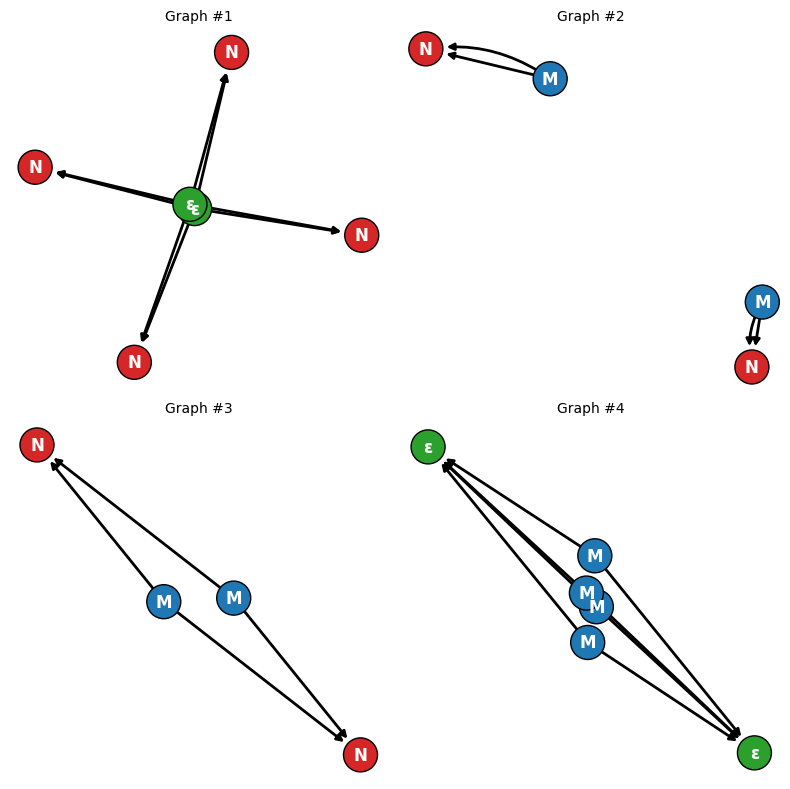

In [2]:
import math
import matplotlib.pyplot as plt
import networkx as nx

def _kind_colour(kind: str) -> str:
    """Return an RGB colour for each node kind."""
    return {
        "M":        "#1f77b4",   # blue
        "N":        "#d62728",   # red
        "EPS_OUT":  "#2ca02c",   # green
        "EPS_IN":   "#2ca02c",   # same green
    }[kind]


def _kind_label(kind: str) -> str:
    """Return a short label to show inside the node."""
    return {
        "M": "M",
        "N": "N",
        "EPS_OUT": "ε",
        "EPS_IN":  "ε",
    }[kind]


def visualize_graphs(order_n: int, *, layout_seed: int = 42) -> None:
    """
    Enumerate every iso‑class at order *n* (using epsilon_graphs) and draw them
    in a tight matplotlib grid.

    Parameters
    ----------
    order_n : int
        |M| + |N| of the graphs to show
    layout_seed : int, default 42
        Spring‑layout seed so the pictures are reproducible
    """
    graphs = list(enumerate_unique_graphs(order_n))
    if not graphs:
        print(f"No graphs exist at order {order_n}")
        return

    k = len(graphs)
    cols = math.ceil(math.sqrt(k))
    rows = math.ceil(k / cols)

    fig, axes = plt.subplots(rows, cols,
                             figsize=(4 * cols, 4 * rows),
                             squeeze=False)
    axes_iter = (ax for row in axes for ax in row)

    for G, ax in zip(graphs, axes_iter):
        pos = nx.spring_layout(G, seed=layout_seed)

        # ---- draw nodes ----------------------------------------------------
        kinds = nx.get_node_attributes(G, "kind")
        node_colors = [_kind_colour(kinds[v]) for v in G.nodes]
        node_labels = {v: _kind_label(kinds[v]) for v in G.nodes}
        nx.draw_networkx_nodes(G, pos,
                               node_color=node_colors,
                               node_size=600,
                               linewidths=1,
                               edgecolors="black",
                               ax=ax)
        nx.draw_networkx_labels(G, pos, labels=node_labels,
                                font_color="white",
                                font_weight="bold",
                                ax=ax)

        # ---- draw (multi‑)edges with slight curvature ----------------------
        # Use the key index to give parallel edges different curvatures
        for (u, v, key) in G.edges(keys=True):
            # map key -> curvature in a small, repeating pattern
            rad_cycle = [0.0, 0.2, -0.2, 0.4, -0.4]
            rad = rad_cycle[key % len(rad_cycle)]
            nx.draw_networkx_edges(
                G, pos, edgelist=[(u, v)],
                connectionstyle=f"arc3,rad={rad}",
                arrows=True,
                arrowstyle="-|>",
                min_source_margin=10,
                min_target_margin=15,
                ax=ax,
                width=2
            )

        ax.set_title(f"Graph #{graphs.index(G)+1}", fontsize=10)
        ax.axis("off")

    # Hide any unused sub‑axes
    for ax in axes_iter:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

visualize_graphs(4)

In [3]:
import math
import matplotlib.pyplot as plt
import networkx as nx

def visualize_graphs_list(graphs, *, layout_seed: int = 42) -> None:
    """
    Visualize a provided list of graphs in a matplotlib grid.

    Parameters
    ----------
    graphs : list of networkx.MultiDiGraph
        The list of graphs to visualize.
    layout_seed : int, default 42
        Seed for spring layout for reproducibility.
    """
    if not graphs:
        print("No graphs to display.")
        return

    k = len(graphs)
    cols = math.ceil(math.sqrt(k))
    rows = math.ceil(k / cols)

    fig, axes = plt.subplots(rows, cols,
                             figsize=(4 * cols, 4 * rows),
                             squeeze=False)
    axes_iter = (ax for row in axes for ax in row)

    for G, ax in zip(graphs, axes_iter):
        pos = nx.spring_layout(G, seed=layout_seed)

        kinds = nx.get_node_attributes(G, "kind")
        node_colors = [_kind_colour(kinds[v]) for v in G.nodes]
        node_labels = {v: _kind_label(kinds[v]) for v in G.nodes}

        nx.draw_networkx_nodes(G, pos,
                               node_color=node_colors,
                               node_size=600,
                               linewidths=1,
                               edgecolors="black",
                               ax=ax)
        nx.draw_networkx_labels(G, pos, labels=node_labels,
                                font_color="white",
                                font_weight="bold",
                                ax=ax)

        for (u, v, key) in G.edges(keys=True):
            rad_cycle = [0.0, 0.2, -0.2, 0.4, -0.4]
            rad = rad_cycle[key % len(rad_cycle)]
            nx.draw_networkx_edges(
                G, pos, edgelist=[(u, v)],
                connectionstyle=f"arc3,rad={rad}",
                arrows=True,
                arrowstyle="-|>",
                min_source_margin=10,
                min_target_margin=15,
                ax=ax,
                width=2
            )

        ax.set_title(f"Graph #{graphs.index(G)+1}", fontsize=10)
        ax.axis("off")

    for ax in axes_iter:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


From a quick glance, it looks like these are all of the correct graphs at each order!

Also note that the number of graphs at each order seems to agree with several OEIS sequences like [this one](<https://oeis.org/A008005>), related to so-called [zeolites](<https://en.wikipedia.org/wiki/Zeolite>) in chemistry. These compounds involve silicon atoms (which make four bonds) and oxygen atoms (which form two bonds), which roughly look like our graphs, where epsilon tensors play the role of silicon and the $M$ and $N$ matrices play the role of oxygens.

Next we need code which will take in a given graph, generate random symmetric $4 \times 4$ matrices, and do the contraction. First we get the random matrices.

In [4]:
def random_sym():
    """
    Generates a random four-by-four symmetric matrix
    """
    pre_output = np.random.randn(4,4)
    symmetrized = (pre_output + pre_output.T)/2.0

    return symmetrized

def levi_civita_4d():
    """
    Returns the 4-dimensional Levi-Civita symbol ε_{i j k l}
    as a NumPy array of shape (4,4,4,4), with values in {0, +1, -1}.
    """
    size = 4
    eps = np.zeros((size,)*4, dtype=int)

    # Only nonzero when (i,j,k,l) is a permutation of (0,1,2,3)
    for perm in permutations(range(size)):
        # Compute inversion count to determine parity
        inv = 0
        for a in range(size):
            for b in range(a+1, size):
                if perm[a] > perm[b]:
                    inv += 1

        eps[perm] = -1 if (inv % 2) else 1

    return eps

## Let's just define epsilon globally to avoid re-computing it every time

epsilon = levi_civita_4d()

Next we need code which plays the role of `graph_to_einsum` and `contract_strings` that we had before. The idea should be to take in a graph of the type we generate above, make one letter for each edge, and then form the appropriate einsum string that corresponds to the contraction that the graph represents. Then we can repeat the steps where we generate random matrices, compute the contractions, and study dependencies.

In [5]:
import opt_einsum as oe

In [6]:
import string

def graph_to_einsum(graph):
    """
    Given a contraction graph with 'kind' attribute on nodes, produce the einsum string.

    Each edge gets a unique label, and each node is represented by the collection
    of incident edge labels.

    Returns
    -------
    einsum_str : str
        The einsum pattern string.
    """
    free_letters = list(string.ascii_letters)
    edge_labels = {}

    # assign unique label to each edge
    for (u, v, key) in graph.edges(keys=True):
        if (u, v, key) not in edge_labels:
            label = free_letters.pop(0)
            edge_labels[(u, v, key)] = label

    # build index string for each node
    node_to_indices = {}
    for node in graph.nodes:
        indices = ''
        for (u, v, key) in graph.edges(keys=True):
            if u == node or v == node:
                indices += edge_labels[(u, v, key)]
        node_to_indices[node] = indices

    einsum_terms = [node_to_indices[n] for n in graph.nodes]
    einsum_str = ','.join(einsum_terms)
    return einsum_str


In [7]:
def filter_connected_graphs(graphs):
    """
    Given a list of networkx graphs, return only the connected graphs.

    Parameters
    ----------
    graphs : list of networkx.MultiDiGraph

    Returns
    -------
    connected_graphs : list of networkx.MultiDiGraph
    """
    connected_graphs = [G for G in graphs if nx.is_weakly_connected(G)]
    return connected_graphs


In [8]:
G2 = list(enumerate_unique_graphs(2))


In [9]:
print(len(G2))

1


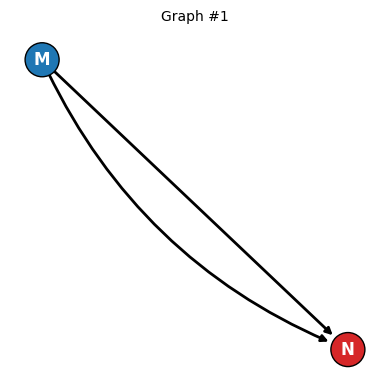

In [10]:
visualize_graphs_list(G2)

In [11]:
data = []

for trial in range(1):
    M = random_sym()
    N = random_sym()

    row = []

    for G in G2:
        # 1) einsum pattern
        pattern = graph_to_einsum(G)

        # 2) assign tensor for each node by its 'kind'
        kinds = nx.get_node_attributes(G, 'kind')
        tensors = []
        for node in G.nodes:
            kind = kinds[node]
            if kind == 'M':
                tensors.append(M)
            elif kind == 'N':
                tensors.append(N)
            elif kind in ('EPS_OUT', 'EPS_IN'):
                tensors.append(epsilon)
            else:
                raise ValueError(f"Unknown kind: {kind}")

        # 3) perform contraction
        val = oe.contract(pattern, *tensors)
        row.append(float(val))

    data.append(row)

print(data)


[[-1.450133217837824]]


In [12]:
np.linalg.matrix_rank(data)

np.int64(1)

In [13]:
G4 = filter_connected_graphs(list(enumerate_unique_graphs(4)))
print(len(G4))

3


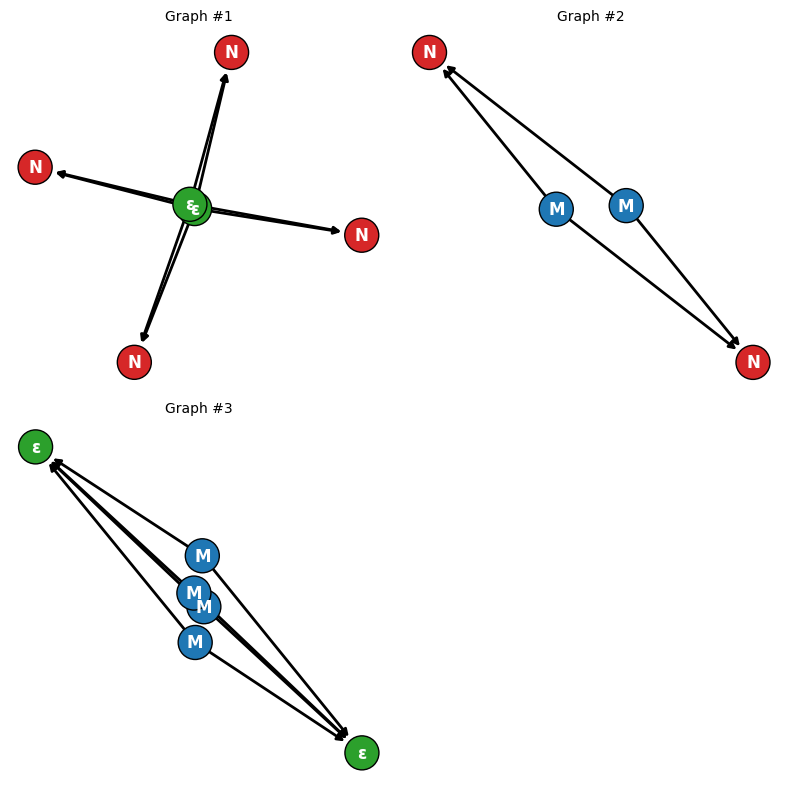

In [14]:
visualize_graphs_list(G4)

In [15]:
data = []

for trial in range(3):
    M = random_sym()
    N = random_sym()

    row = []


    for G in G4:
        # 1) einsum pattern
        pattern = graph_to_einsum(G)

        # 2) assign tensor for each node by its 'kind'
        kinds = nx.get_node_attributes(G, 'kind')
        tensors = []
        for node in G.nodes:
            kind = kinds[node]
            if kind == 'M':
                tensors.append(M)
            elif kind == 'N':
                tensors.append(N)
            elif kind in ('EPS_OUT', 'EPS_IN'):
                tensors.append(epsilon)
            else:
                raise ValueError(f"Unknown kind: {kind}")

        # 3) perform contraction
        val = oe.contract(pattern, *tensors)
        row.append(float(val))

    data.append(row)

print(data)


[[1.85856514838959, 8.308562104681156, 4.846744167175584], [253.59457626349456, -0.3083856869347348, -14.785372545885654], [-7.068392433936992, 14.035309571502154, 2.3711587755126473]]


In [16]:
np.linalg.matrix_rank(data)

np.int64(3)

In [17]:
import numpy as np

data = []


for i in range(4):
    M = random_sym()
    N = random_sym()

    y2 = []
    y4 = []

    for G in G2:
        pattern = graph_to_einsum(G)

        kinds = nx.get_node_attributes(G, 'kind')
        tensors = []
        for node in G.nodes:
            kind = kinds[node]
            if kind == 'M':
                tensors.append(M)
            elif kind == 'N':
                tensors.append(N)
            elif kind in ('EPS_OUT', 'EPS_IN'):
                tensors.append(epsilon)
            else:
                raise ValueError(f"Unknown kind: {kind}")

        val = oe.contract(pattern, *tensors)
        y2.append(float(val))

    for G in G4:
        pattern = graph_to_einsum(G)

        kinds = nx.get_node_attributes(G, 'kind')
        tensors = []
        for node in G.nodes:
            kind = kinds[node]
            if kind == 'M':
                tensors.append(M)
            elif kind == 'N':
                tensors.append(N)
            elif kind in ('EPS_OUT', 'EPS_IN'):
                tensors.append(epsilon)
            else:
                raise ValueError(f"Unknown kind: {kind}")

        val = oe.contract(pattern, *tensors)
        y4.append(float(val))

    # form the row: square of first order-2 invariant + all order-4 invariants
    row = []
    row.append(y2[0] * y2[0])
    row.append(y4[0])
    row.append(y4[1])
    row.append(y4[2])
    data.append(row)

data = np.array(data)
print(data.shape, np.linalg.matrix_rank(data))


(4, 4) 4


In [18]:
indep_G4_v1 =  [G4[0],  G4[1], G4[2]]

7


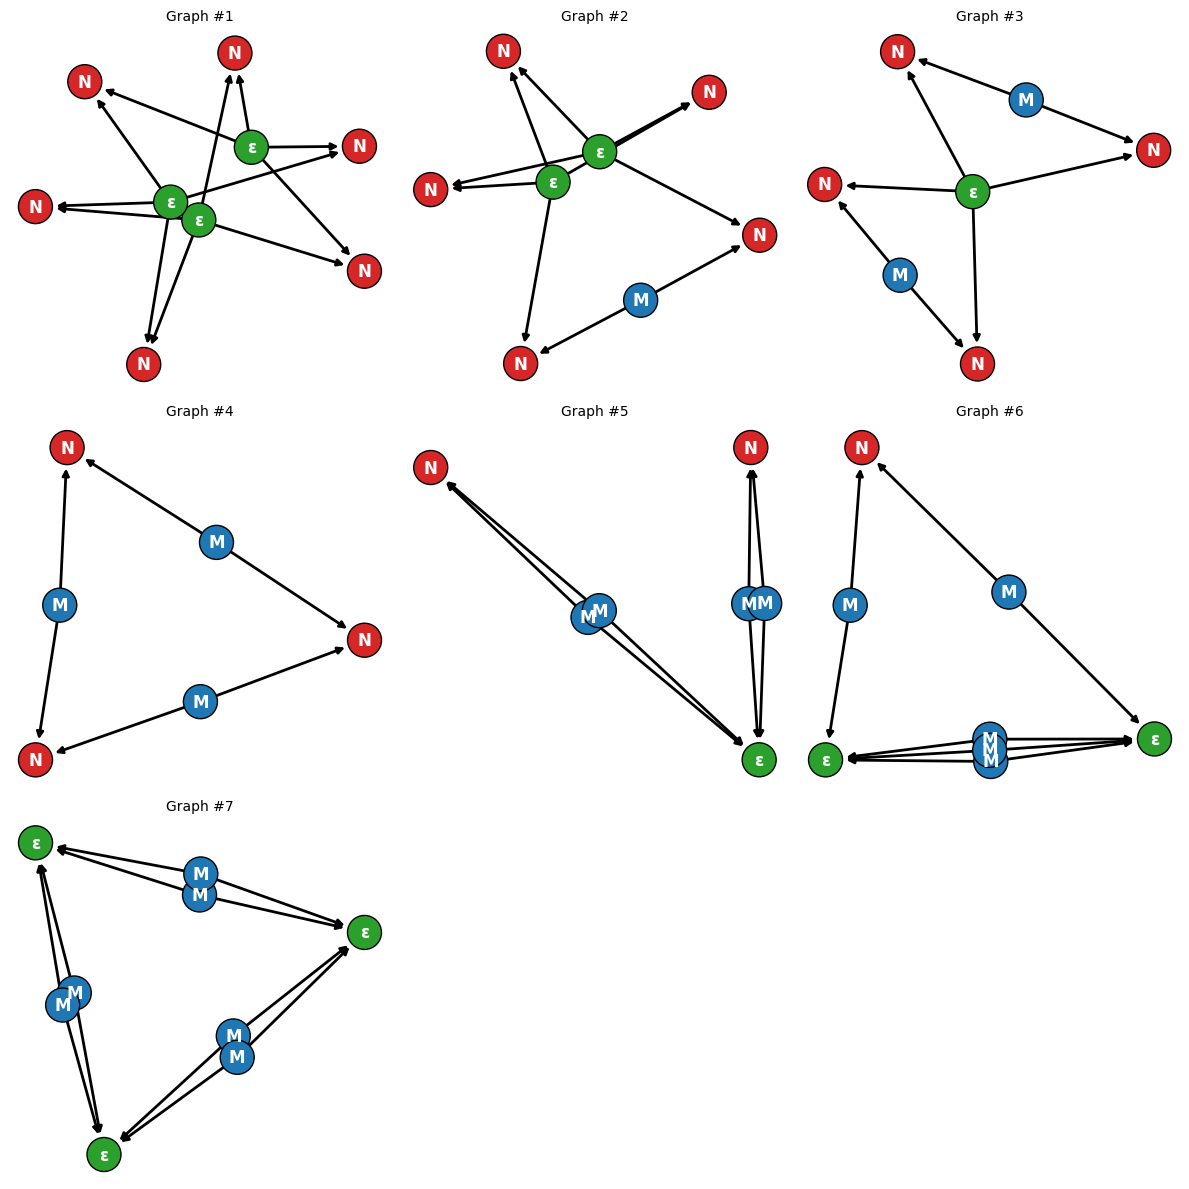

In [19]:
G6 = filter_connected_graphs(list(enumerate_unique_graphs(6)))
print(len(G6))
visualize_graphs_list(G6)

In [20]:
data = []

for trial in range(7):
    M = random_sym()
    N = random_sym()

    row = []


    for G in G6:
        # 1) einsum pattern
        pattern = graph_to_einsum(G)

        # 2) assign tensor for each node by its 'kind'
        kinds = nx.get_node_attributes(G, 'kind')
        tensors = []
        for node in G.nodes:
            kind = kinds[node]
            if kind == 'M':
                tensors.append(M)
            elif kind == 'N':
                tensors.append(N)
            elif kind in ('EPS_OUT', 'EPS_IN'):
                tensors.append(epsilon)
            else:
                raise ValueError(f"Unknown kind: {kind}")

        # 3) perform contraction
        val = oe.contract(pattern, *tensors)
        row.append(float(val))

    data.append(row)

print(data)


[[-1.1129540898738013e-15, -5.565036352834569, 1.9721522630525295e-31, 1.9262143995006635, 0.0, -4.744381131128975, 2.409519409197081e-16], [-3.776397250184804e-16, 2.7332756215740783, 1.9721522630525295e-31, 9.481172014162873, -2.465190328815662e-32, -3.0130866899382642, 1.5272228809126646e-16], [6.270932552610844e-18, 4.281312658370976, 0.0, -1.0136472422271008, 2.465190328815662e-32, -69.90517547535039, -1.1365548075704832e-14], [7.811893868117831e-16, 6.8961131474230655, -4.930380657631324e-32, 8.498763290579802, 2.465190328815662e-32, 7.63236761085261, -1.3228555417612164e-15], [-1.2142566692843702e-15, -13.667190319943483, -9.860761315262648e-32, 28.741566489100528, -5.084455053182303e-32, -28.00570097220251, 3.7520217116730535e-15], [-1.2674832104250994e-17, -0.18880186113635, 0.0, 17.838348199834908, 0.0, 0.48495678769070505, 3.6682235942135626e-16], [-2.970505324832297e-15, 13.4789209799812, 0.0, 66.33591080906591, 0.0, -15.04869716994791, -2.8933468653018104e-15]]


In [21]:
np.linalg.matrix_rank(data)

np.int64(3)

In [22]:
data = np.array(data).T.tolist()


In [23]:
indep_cols = []   # selected column vectors (shape: n_samples,)
indep_idx  = []   # their original column indices

fixed_tol = 1e-6

for idx, vec in enumerate(data):   # iterate over columns
    M = np.vstack(indep_cols + [vec])

    # singular values
    _, S, _ = np.linalg.svd(M)
    rank = np.sum(S > fixed_tol)

    if rank == len(indep_cols) + 1:
        indep_cols.append(vec)
        indep_idx.append(idx)

print("Independent invariant indices:", indep_idx)


Independent invariant indices: [1, 3, 5]


In [24]:
indep_G6_v1 = [G6[1], G6[3], G6[5]]

In [25]:
print(len(indep_G6_v1))

3


In [26]:
import numpy as np

data = []



for i in range(7):
    M = random_sym()
    N = random_sym()

    y2 = []
    y4 = []
    y6 = []

    for G in G2:
        pattern = graph_to_einsum(G)

        kinds = nx.get_node_attributes(G, 'kind')
        tensors = []
        for node in G.nodes:
            kind = kinds[node]
            if kind == 'M':
                tensors.append(M)
            elif kind == 'N':
                tensors.append(N)
            elif kind in ('EPS_OUT', 'EPS_IN'):
                tensors.append(epsilon)
            else:
                raise ValueError(f"Unknown kind: {kind}")

        val = oe.contract(pattern, *tensors)
        y2.append(float(val))

    for G in indep_G4_v1:
        pattern = graph_to_einsum(G)

        kinds = nx.get_node_attributes(G, 'kind')
        tensors = []
        for node in G.nodes:
            kind = kinds[node]
            if kind == 'M':
                tensors.append(M)
            elif kind == 'N':
                tensors.append(N)
            elif kind in ('EPS_OUT', 'EPS_IN'):
                tensors.append(epsilon)
            else:
                raise ValueError(f"Unknown kind: {kind}")

        val = oe.contract(pattern, *tensors)
        y4.append(float(val))

    for G in indep_G6_v1:
        pattern = graph_to_einsum(G)

        kinds = nx.get_node_attributes(G, 'kind')
        tensors = []
        for node in G.nodes:
            kind = kinds[node]
            if kind == 'M':
                tensors.append(M)
            elif kind == 'N':
                tensors.append(N)
            elif kind in ('EPS_OUT', 'EPS_IN'):
                tensors.append(epsilon)
            else:
                raise ValueError(f"Unknown kind: {kind}")

        val = oe.contract(pattern, *tensors)
        y6.append(float(val))
    # form the row: square of first order-2 invariant + all order-4 invariants
    row = []
    row.append(y2[0] * y2[0]* y2[0])
    row.append(y4[0]*y2[0])
    row.append(y4[1]*y2[0])
    row.append(y4[2]*y2[0])
    row.append(y6[0])
    row.append(y6[1])
    row.append(y6[2])

    data.append(row)

data = np.array(data)
print(data.shape, np.linalg.matrix_rank(data))


(7, 7) 5


In [27]:
import numpy as np

data = []



for i in range(5):
    M = random_sym()
    N = random_sym()

    y2 = []
    y4 = []
    y6 = []

    for G in G2:
        pattern = graph_to_einsum(G)

        kinds = nx.get_node_attributes(G, 'kind')
        tensors = []
        for node in G.nodes:
            kind = kinds[node]
            if kind == 'M':
                tensors.append(M)
            elif kind == 'N':
                tensors.append(N)
            elif kind in ('EPS_OUT', 'EPS_IN'):
                tensors.append(epsilon)
            else:
                raise ValueError(f"Unknown kind: {kind}")

        val = oe.contract(pattern, *tensors)
        y2.append(float(val))

    for G in indep_G4_v1:
        pattern = graph_to_einsum(G)

        kinds = nx.get_node_attributes(G, 'kind')
        tensors = []
        for node in G.nodes:
            kind = kinds[node]
            if kind == 'M':
                tensors.append(M)
            elif kind == 'N':
                tensors.append(N)
            elif kind in ('EPS_OUT', 'EPS_IN'):
                tensors.append(epsilon)
            else:
                raise ValueError(f"Unknown kind: {kind}")

        val = oe.contract(pattern, *tensors)
        y4.append(float(val))

    for G in indep_G6_v1:
        pattern = graph_to_einsum(G)

        kinds = nx.get_node_attributes(G, 'kind')
        tensors = []
        for node in G.nodes:
            kind = kinds[node]
            if kind == 'M':
                tensors.append(M)
            elif kind == 'N':
                tensors.append(N)
            elif kind in ('EPS_OUT', 'EPS_IN'):
                tensors.append(epsilon)
            else:
                raise ValueError(f"Unknown kind: {kind}")

        val = oe.contract(pattern, *tensors)
        y6.append(float(val))
    # form the row: square of first order-2 invariant + all order-4 invariants
    row = []
    row.append(y2[0] * y2[0]* y2[0])
    row.append(y4[0]*y2[0])
    row.append(y4[1]*y2[0])
    row.append(y4[2]*y2[0])
    #row.append(y6[0])
    row.append(y6[1])
    #row.append(y6[2])

    data.append(row)

data = np.array(data)
print(data.shape, np.linalg.matrix_rank(data))


(5, 5) 5


In [28]:
indep_G6_v2 = [indep_G6_v1[1]]

10


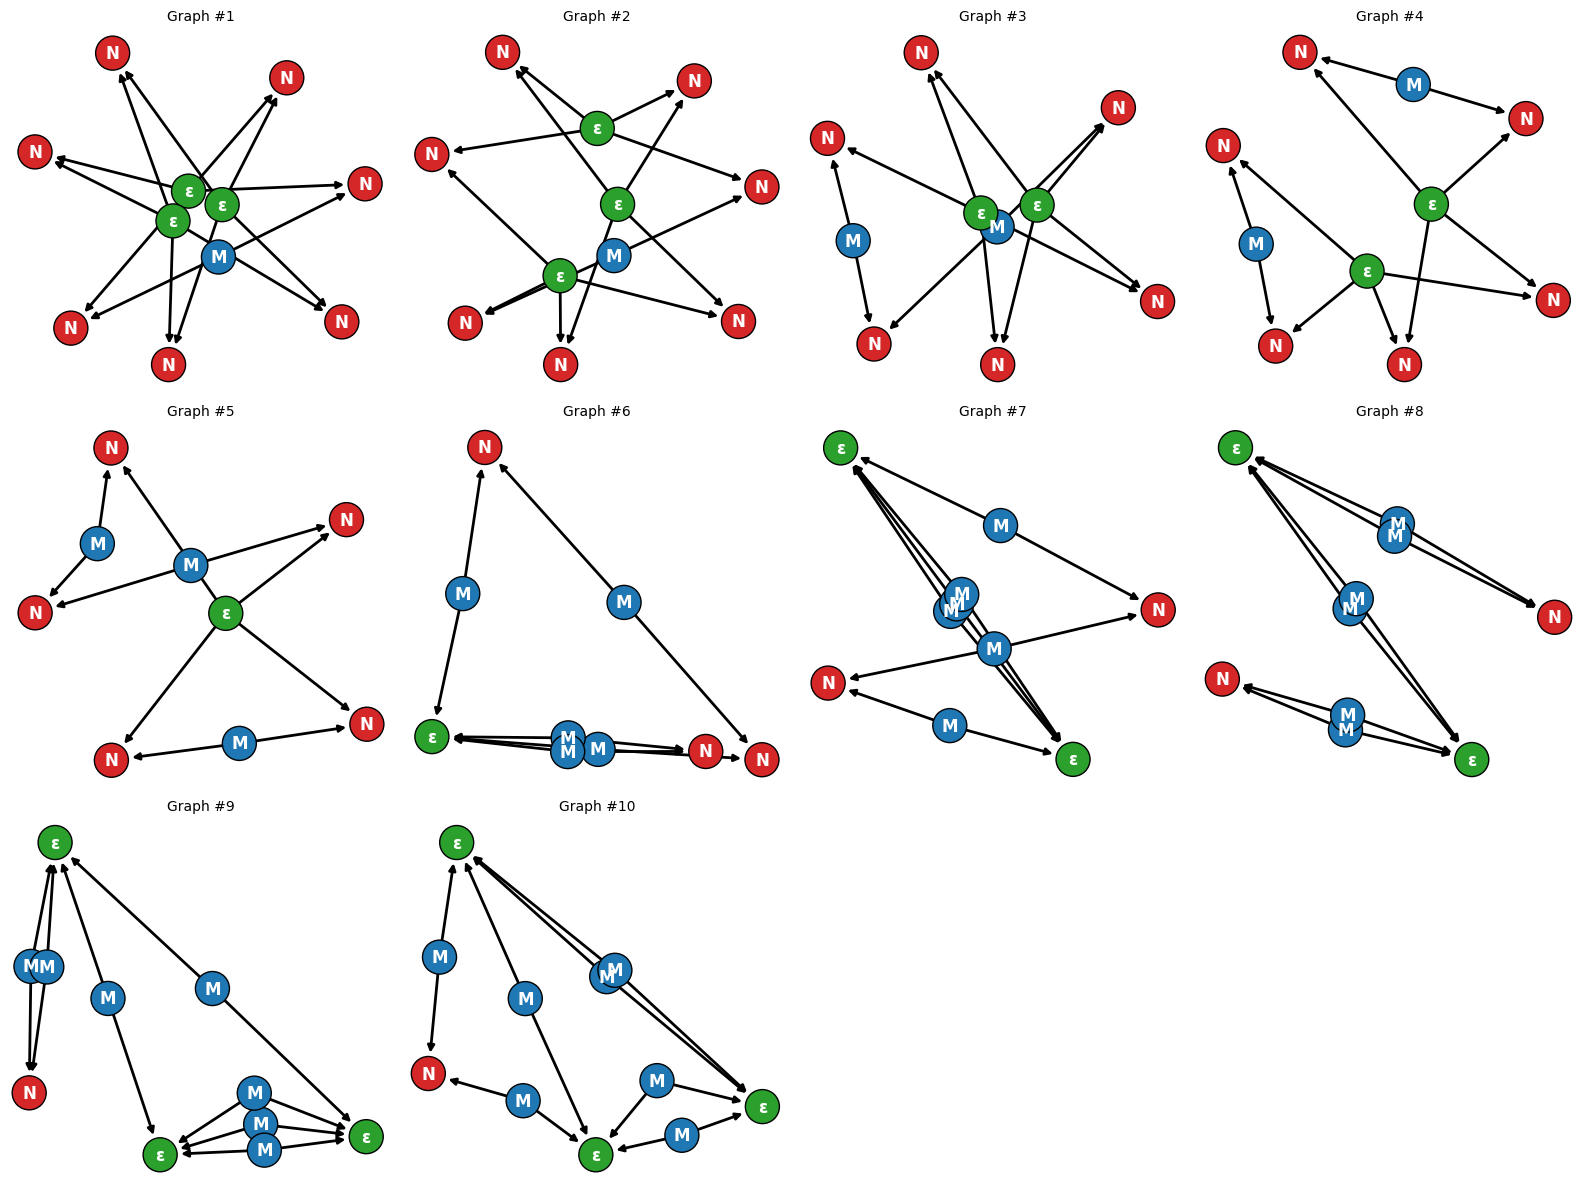

In [29]:
G8 = filter_connected_graphs(list(enumerate_unique_graphs(8)))
print(len(G8))
visualize_graphs_list(G8)

In [30]:
data = []

for trial in range(10):
    M = random_sym()
    N = random_sym()

    row = []


    for G in G8:
        # 1) einsum pattern
        pattern = graph_to_einsum(G)

        # 2) assign tensor for each node by its 'kind'
        kinds = nx.get_node_attributes(G, 'kind')
        tensors = []
        for node in G.nodes:
            kind = kinds[node]
            if kind == 'M':
                tensors.append(M)
            elif kind == 'N':
                tensors.append(N)
            elif kind in ('EPS_OUT', 'EPS_IN'):
                tensors.append(epsilon)
            else:
                raise ValueError(f"Unknown kind: {kind}")

        # 3) perform contraction
        val = oe.contract(pattern, *tensors)
        row.append(float(val))

    data.append(row)

print(data)


[[-9.860761315262648e-32, 1.2325757600875233e-16, -98.41670311794812, -4.959898688135344e-31, 3.1554436208840472e-30, 1.1832913578315177e-30, 214.24666042061125, 1.2365348906883898e-31, -4.733165431326071e-30, -1.0108811189636894e-15], [3.1554436208840472e-30, 1.929713155305898e-14, -256.73290066100367, 1.988673171501869e-31, 0.0, 0.0, -11.743640665745037, -6.631413501808665e-33, 0.0, -3.859305117238904e-18], [2.465190328815662e-32, -1.7959553552649614e-17, 0.3768477932226997, 9.532691482581731e-34, 0.0, 9.244463733058732e-33, 0.40568648807438834, -2.2492857569688448e-32, 1.232595164407831e-32, -7.642708354981379e-17], [5.9164567891575885e-31, 3.4139264113224065e-16, -56.817986902898696, 2.241742201062339e-30, 7.888609052210118e-31, 7.888609052210118e-31, 333.11865220250104, -1.0744665121285257e-30, 1.5777218104420236e-30, 6.421687422676062e-15], [-7.888609052210118e-31, 1.1439765998329472e-15, -0.31617394857913794, -5.0260494834540435e-31, 4.930380657631324e-32, 1.4791141972893971e-31

In [31]:
np.linalg.matrix_rank(data)

np.int64(2)

In [32]:
data = np.array(data).T.tolist()


In [33]:
indep_cols = []   # selected column vectors (shape: n_samples,)
indep_idx  = []   # their original column indices

fixed_tol = 1e-6

for idx, vec in enumerate(data):   # iterate over columns
    M = np.vstack(indep_cols + [vec])

    # singular values
    _, S, _ = np.linalg.svd(M)
    rank = np.sum(S > fixed_tol)

    if rank == len(indep_cols) + 1:
        indep_cols.append(vec)
        indep_idx.append(idx)

print("Independent invariant indices:", indep_idx)


Independent invariant indices: [2, 6]


In [34]:
indep_G8_v1 = [G8[2], G8[6]]

In [35]:
import numpy as np

data = []



for i in range(13):
    M = random_sym()
    N = random_sym()

    y2 = []
    y4 = []
    y6 = []
    y8 = []
    for G in G2:
        pattern = graph_to_einsum(G)

        kinds = nx.get_node_attributes(G, 'kind')
        tensors = []
        for node in G.nodes:
            kind = kinds[node]
            if kind == 'M':
                tensors.append(M)
            elif kind == 'N':
                tensors.append(N)
            elif kind in ('EPS_OUT', 'EPS_IN'):
                tensors.append(epsilon)
            else:
                raise ValueError(f"Unknown kind: {kind}")

        val = oe.contract(pattern, *tensors)
        y2.append(float(val))

    for G in indep_G4_v1:
        pattern = graph_to_einsum(G)

        kinds = nx.get_node_attributes(G, 'kind')
        tensors = []
        for node in G.nodes:
            kind = kinds[node]
            if kind == 'M':
                tensors.append(M)
            elif kind == 'N':
                tensors.append(N)
            elif kind in ('EPS_OUT', 'EPS_IN'):
                tensors.append(epsilon)
            else:
                raise ValueError(f"Unknown kind: {kind}")

        val = oe.contract(pattern, *tensors)
        y4.append(float(val))

    for G in indep_G6_v2:
        pattern = graph_to_einsum(G)

        kinds = nx.get_node_attributes(G, 'kind')
        tensors = []
        for node in G.nodes:
            kind = kinds[node]
            if kind == 'M':
                tensors.append(M)
            elif kind == 'N':
                tensors.append(N)
            elif kind in ('EPS_OUT', 'EPS_IN'):
                tensors.append(epsilon)
            else:
                raise ValueError(f"Unknown kind: {kind}")

        val = oe.contract(pattern, *tensors)
        y6.append(float(val))


    for G in indep_G8_v1:
        pattern = graph_to_einsum(G)

        kinds = nx.get_node_attributes(G, 'kind')
        tensors = []
        for node in G.nodes:
            kind = kinds[node]
            if kind == 'M':
                tensors.append(M)
            elif kind == 'N':
                tensors.append(N)
            elif kind in ('EPS_OUT', 'EPS_IN'):
                tensors.append(epsilon)
            else:
                raise ValueError(f"Unknown kind: {kind}")

        val = oe.contract(pattern, *tensors)
        y8.append(float(val))

    # form the row: square of first order-2 invariant + all order-4 invariants
    row = []
    row.append(y2[0] * y2[0]* y2[0]* y2[0])
    row.append(y4[0]*y2[0]* y2[0])
    row.append(y4[1]*y2[0]* y2[0])
    row.append(y4[2]*y2[0]* y2[0])
    row.append(y4[0] * y4[0])
    row.append(y4[0] * y4[1])
    row.append(y4[0] * y4[2])
    row.append(y4[1] * y4[1])
    row.append(y4[1] * y4[2])
    row.append(y4[2] * y4[2])
    row.append(y2[0] * y6[0])

    row.append(y8[0])
    row.append(y8[1])





    data.append(row)

data = np.array(data)
print(data.shape, np.linalg.matrix_rank(data))


(13, 13) 11


In [36]:
import numpy as np

data = []



for i in range(11):
    M = random_sym()
    N = random_sym()

    y2 = []
    y4 = []
    y6 = []
    y8 = []
    for G in G2:
        pattern = graph_to_einsum(G)

        kinds = nx.get_node_attributes(G, 'kind')
        tensors = []
        for node in G.nodes:
            kind = kinds[node]
            if kind == 'M':
                tensors.append(M)
            elif kind == 'N':
                tensors.append(N)
            elif kind in ('EPS_OUT', 'EPS_IN'):
                tensors.append(epsilon)
            else:
                raise ValueError(f"Unknown kind: {kind}")

        val = oe.contract(pattern, *tensors)
        y2.append(float(val))

    for G in indep_G4_v1:
        pattern = graph_to_einsum(G)

        kinds = nx.get_node_attributes(G, 'kind')
        tensors = []
        for node in G.nodes:
            kind = kinds[node]
            if kind == 'M':
                tensors.append(M)
            elif kind == 'N':
                tensors.append(N)
            elif kind in ('EPS_OUT', 'EPS_IN'):
                tensors.append(epsilon)
            else:
                raise ValueError(f"Unknown kind: {kind}")

        val = oe.contract(pattern, *tensors)
        y4.append(float(val))

    for G in indep_G6_v2:
        pattern = graph_to_einsum(G)

        kinds = nx.get_node_attributes(G, 'kind')
        tensors = []
        for node in G.nodes:
            kind = kinds[node]
            if kind == 'M':
                tensors.append(M)
            elif kind == 'N':
                tensors.append(N)
            elif kind in ('EPS_OUT', 'EPS_IN'):
                tensors.append(epsilon)
            else:
                raise ValueError(f"Unknown kind: {kind}")

        val = oe.contract(pattern, *tensors)
        y6.append(float(val))


    for G in indep_G8_v1:
        pattern = graph_to_einsum(G)

        kinds = nx.get_node_attributes(G, 'kind')
        tensors = []
        for node in G.nodes:
            kind = kinds[node]
            if kind == 'M':
                tensors.append(M)
            elif kind == 'N':
                tensors.append(N)
            elif kind in ('EPS_OUT', 'EPS_IN'):
                tensors.append(epsilon)
            else:
                raise ValueError(f"Unknown kind: {kind}")

        val = oe.contract(pattern, *tensors)
        y8.append(float(val))

    # form the row: square of first order-2 invariant + all order-4 invariants
    row = []
    row.append(y2[0] * y2[0]* y2[0]* y2[0])
    row.append(y4[0]*y2[0]* y2[0])
    row.append(y4[1]*y2[0]* y2[0])
    row.append(y4[2]*y2[0]* y2[0])
    row.append(y4[0] * y4[0])
    row.append(y4[0] * y4[1])
    row.append(y4[0] * y4[2])
    row.append(y4[1] * y4[1])
    row.append(y4[1] * y4[2])
    row.append(y4[2] * y4[2])
    row.append(y2[0] * y6[0])

    #row.append(y8[0])
    #row.append(y8[1])





    data.append(row)

data = np.array(data)
print(data.shape, np.linalg.matrix_rank(data))


(11, 11) 11


In [37]:
G10 = filter_connected_graphs(list(enumerate_unique_graphs(10)))
print(len(G10))


28


In [38]:
data = []

for trial in range(28):
    M = random_sym()
    N = random_sym()

    row = []


    for G in G10:
        # 1) einsum pattern
        pattern = graph_to_einsum(G)

        # 2) assign tensor for each node by its 'kind'
        kinds = nx.get_node_attributes(G, 'kind')
        tensors = []
        for node in G.nodes:
            kind = kinds[node]
            if kind == 'M':
                tensors.append(M)
            elif kind == 'N':
                tensors.append(N)
            elif kind in ('EPS_OUT', 'EPS_IN'):
                tensors.append(epsilon)
            else:
                raise ValueError(f"Unknown kind: {kind}")

        # 3) perform contraction
        val = oe.contract(pattern, *tensors)
        row.append(float(val))

    data.append(row)

print(data)


[[1.1401505270772436e-31, -0.23547127891337682, -0.15698085260891503, -0.23547127891337677, -4.129193800766234e-31, -6.458160045906869e-16, 9.860761315262648e-32, -2.6578737865007282e-33, -1.89511506527704e-31, -1.9701834938391432, -9.860761315262648e-32, -3.839875484125421e-32, -1.232595164407831e-32, 0.0, -1.5407439555097887e-33, 0.0, 5.754337117314316, -1.5407439555097887e-33, 1.0735791805478469e-33, 0.0, 2.9938473123660314e-17, 0.0, -3.0323757419486354e-35, 0.0, 0.0, -2.0087005242622586, -1.3391336828415057, -2.008700524262258], [3.1554436208840472e-30, -502.9138910548203, -335.27592736988026, -502.9138910548204, 2.514494135391975e-30, -1.084539474069015e-14, 3.1554436208840472e-30, -8.208379827934157e-31, -3.1554436208840472e-30, 451.07658295035156, -2.3665827156630354e-30, 4.8122701760277205e-31, -3.944304526105059e-31, 1.5777218104420236e-30, -3.944304526105059e-31, 1.9721522630525295e-30, 54.47143790247469, 2.9582283945787943e-31, 1.829104166699905e-31, 1.9721522630525295e-31, 

In [39]:
A = data

    # singular values
_, S, _ = np.linalg.svd(A)

    # custom fixed threshold (say 1e-6)
fixed_tol = 1e-6

    # count singular values above that threshold
rank = np.sum(S > fixed_tol)

print(f" rank = {rank}")


 rank = 4


In [40]:
np.linalg.matrix_rank(data)

np.int64(4)

In [41]:
data = np.array(data).T.tolist()
indep_cols = []   # selected column vectors (shape: n_samples,)
indep_idx  = []   # their original column indices

fixed_tol = 1e-6

for idx, vec in enumerate(data):   # iterate over columns
    M = np.vstack(indep_cols + [vec])

    # singular values
    _, S, _ = np.linalg.svd(M)
    rank = np.sum(S > fixed_tol)

    if rank == len(indep_cols) + 1:
        indep_cols.append(vec)
        indep_idx.append(idx)

print("Independent invariant indices:", indep_idx)


Independent invariant indices: [1, 9, 16, 25]


In [42]:
indep_G10_v1 = [G10[1], G10[9], G10[16], G10[25]]

In [43]:
import numpy as np

data = []



for i in range(18):
    M = random_sym()
    N = random_sym()

    y2 = []
    y4 = []
    y6 = []
    y10 = []
    for G in G2:
        pattern = graph_to_einsum(G)

        kinds = nx.get_node_attributes(G, 'kind')
        tensors = []
        for node in G.nodes:
            kind = kinds[node]
            if kind == 'M':
                tensors.append(M)
            elif kind == 'N':
                tensors.append(N)
            elif kind in ('EPS_OUT', 'EPS_IN'):
                tensors.append(epsilon)
            else:
                raise ValueError(f"Unknown kind: {kind}")

        val = oe.contract(pattern, *tensors)
        y2.append(float(val))

    for G in indep_G4_v1:
        pattern = graph_to_einsum(G)

        kinds = nx.get_node_attributes(G, 'kind')
        tensors = []
        for node in G.nodes:
            kind = kinds[node]
            if kind == 'M':
                tensors.append(M)
            elif kind == 'N':
                tensors.append(N)
            elif kind in ('EPS_OUT', 'EPS_IN'):
                tensors.append(epsilon)
            else:
                raise ValueError(f"Unknown kind: {kind}")

        val = oe.contract(pattern, *tensors)
        y4.append(float(val))

    for G in indep_G6_v2:
        pattern = graph_to_einsum(G)

        kinds = nx.get_node_attributes(G, 'kind')
        tensors = []
        for node in G.nodes:
            kind = kinds[node]
            if kind == 'M':
                tensors.append(M)
            elif kind == 'N':
                tensors.append(N)
            elif kind in ('EPS_OUT', 'EPS_IN'):
                tensors.append(epsilon)
            else:
                raise ValueError(f"Unknown kind: {kind}")

        val = oe.contract(pattern, *tensors)
        y6.append(float(val))


    for G in indep_G10_v1:
        pattern = graph_to_einsum(G)

        kinds = nx.get_node_attributes(G, 'kind')
        tensors = []
        for node in G.nodes:
            kind = kinds[node]
            if kind == 'M':
                tensors.append(M)
            elif kind == 'N':
                tensors.append(N)
            elif kind in ('EPS_OUT', 'EPS_IN'):
                tensors.append(epsilon)
            else:
                raise ValueError(f"Unknown kind: {kind}")

        val = oe.contract(pattern, *tensors)
        y10.append(float(val))

    # form the row: square of first order-2 invariant + all order-4 invariants
    row = []
    row.append(y2[0] * y2[0]* y2[0]* y2[0]* y2[0])
    row.append(y4[0]*y2[0]* y2[0]* y2[0])
    row.append(y4[1]*y2[0]* y2[0]* y2[0])
    row.append(y4[2]*y2[0]* y2[0]* y2[0])
    row.append(y4[0] * y4[0]* y2[0])
    row.append(y4[0] * y4[1]* y2[0])
    row.append(y4[0] * y4[2]* y2[0])
    row.append(y4[1] * y4[1]* y2[0])
    row.append(y4[1] * y4[2]* y2[0])
    row.append(y4[2] * y4[2]* y2[0])
    row.append(y6[0] * y2[0]* y2[0])
    row.append(y6[0] * y4[0])
    row.append(y6[0] * y4[1])
    row.append(y6[0] * y4[2])

    row.append(y10[0] )
    row.append(y10[1] )
    row.append(y10[2] )
    row.append(y10[3] )







    data.append(row)

data = np.array(data)
print(data.shape, np.linalg.matrix_rank(data))


(18, 18) 14


In [44]:
import numpy as np

data = []



for i in range(14):
    M = random_sym()
    N = random_sym()

    y2 = []
    y4 = []
    y6 = []
    y8 = []
    y10 = []
    for G in G2:
        pattern = graph_to_einsum(G)

        kinds = nx.get_node_attributes(G, 'kind')
        tensors = []
        for node in G.nodes:
            kind = kinds[node]
            if kind == 'M':
                tensors.append(M)
            elif kind == 'N':
                tensors.append(N)
            elif kind in ('EPS_OUT', 'EPS_IN'):
                tensors.append(epsilon)
            else:
                raise ValueError(f"Unknown kind: {kind}")

        val = oe.contract(pattern, *tensors)
        y2.append(float(val))

    for G in indep_G4_v1:
        pattern = graph_to_einsum(G)

        kinds = nx.get_node_attributes(G, 'kind')
        tensors = []
        for node in G.nodes:
            kind = kinds[node]
            if kind == 'M':
                tensors.append(M)
            elif kind == 'N':
                tensors.append(N)
            elif kind in ('EPS_OUT', 'EPS_IN'):
                tensors.append(epsilon)
            else:
                raise ValueError(f"Unknown kind: {kind}")

        val = oe.contract(pattern, *tensors)
        y4.append(float(val))

    for G in indep_G6_v2:
        pattern = graph_to_einsum(G)

        kinds = nx.get_node_attributes(G, 'kind')
        tensors = []
        for node in G.nodes:
            kind = kinds[node]
            if kind == 'M':
                tensors.append(M)
            elif kind == 'N':
                tensors.append(N)
            elif kind in ('EPS_OUT', 'EPS_IN'):
                tensors.append(epsilon)
            else:
                raise ValueError(f"Unknown kind: {kind}")

        val = oe.contract(pattern, *tensors)
        y6.append(float(val))


    for G in indep_G10_v1:
        pattern = graph_to_einsum(G)

        kinds = nx.get_node_attributes(G, 'kind')
        tensors = []
        for node in G.nodes:
            kind = kinds[node]
            if kind == 'M':
                tensors.append(M)
            elif kind == 'N':
                tensors.append(N)
            elif kind in ('EPS_OUT', 'EPS_IN'):
                tensors.append(epsilon)
            else:
                raise ValueError(f"Unknown kind: {kind}")

        val = oe.contract(pattern, *tensors)
        y10.append(float(val))

    # form the row: square of first order-2 invariant + all order-4 invariants
    row = []
    row.append(y2[0] * y2[0]* y2[0]* y2[0]* y2[0])
    row.append(y4[0]*y2[0]* y2[0]* y2[0])
    row.append(y4[1]*y2[0]* y2[0]* y2[0])
    row.append(y4[2]*y2[0]* y2[0]* y2[0])
    row.append(y4[0] * y4[0]* y2[0])
    row.append(y4[0] * y4[1]* y2[0])
    row.append(y4[0] * y4[2]* y2[0])
    row.append(y4[1] * y4[1]* y2[0])
    row.append(y4[1] * y4[2]* y2[0])
    row.append(y4[2] * y4[2]* y2[0])
    row.append(y6[0] * y2[0]* y2[0])
    row.append(y6[0] * y4[0])
    row.append(y6[0] * y4[1])
    row.append(y6[0] * y4[2])
    #row.append(y10[0] )
    #row.append(y10[1] )
    #row.append(y10[2] )
    #row.append(y10[3] )







    data.append(row)

data = np.array(data)
print(data.shape, np.linalg.matrix_rank(data))


(14, 14) 14


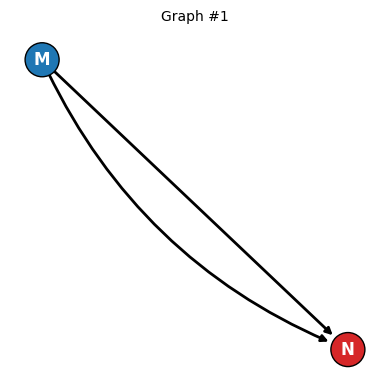

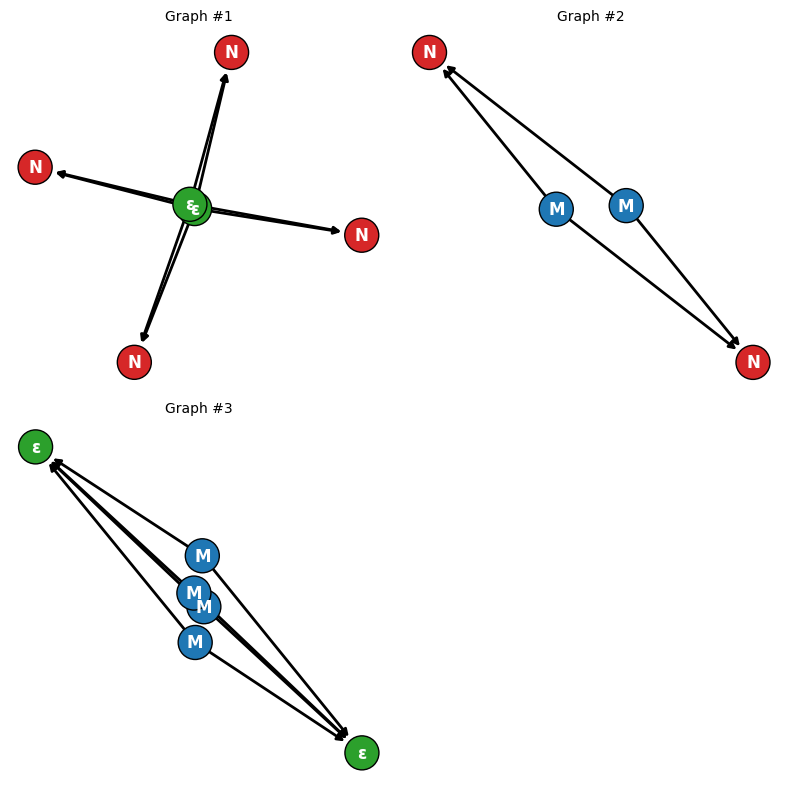

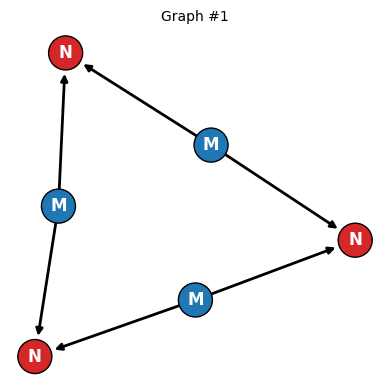

In [45]:
visualize_graphs_list(G2)
visualize_graphs_list(indep_G4_v1)
visualize_graphs_list(indep_G6_v2)

In [46]:
import numpy as np
from itertools import product
import networkx as nx
import opt_einsum as oe

def generate_monomials(target_sum):
    monomials = []
    for a in range(target_sum // 2 + 1):
        for b0 in range(target_sum // 4 + 1):
            for b1 in range(target_sum // 4 + 1):
                for b2 in range(target_sum // 4 + 1):
                    for c in range(target_sum // 6 + 1):
                        total = 2*a + 4*(b0 + b1 + b2) + 6*c
                        if total == target_sum:
                            monomials.append((a, b0, b1, b2, c))
    return monomials

for total_order in range(10, 51, 2):
    monomials = generate_monomials(total_order)
    data = []

    for _ in range(len(monomials)):

        y2 = []
        y4 = []
        y6 = []

        M = random_sym()
        N = random_sym()

        for G in G2:
            pattern = graph_to_einsum(G)

            kinds = nx.get_node_attributes(G, 'kind')
            tensors = []
            for node in G.nodes:
                kind = kinds[node]
                if kind == 'M':
                    tensors.append(M)
                elif kind == 'N':
                    tensors.append(N)
                elif kind in ('EPS_OUT', 'EPS_IN'):
                    tensors.append(epsilon)
                else:
                    raise ValueError(f"Unknown kind: {kind}")

            val = oe.contract(pattern, *tensors)
            y2.append(float(val))

        for G in indep_G4_v1:
            pattern = graph_to_einsum(G)

            kinds = nx.get_node_attributes(G, 'kind')
            tensors = []
            for node in G.nodes:
                kind = kinds[node]
                if kind == 'M':
                    tensors.append(M)
                elif kind == 'N':
                    tensors.append(N)
                elif kind in ('EPS_OUT', 'EPS_IN'):
                    tensors.append(epsilon)
                else:
                    raise ValueError(f"Unknown kind: {kind}")

            val = oe.contract(pattern, *tensors)
            y4.append(float(val))

        for G in indep_G6_v2:
            pattern = graph_to_einsum(G)

            kinds = nx.get_node_attributes(G, 'kind')
            tensors = []
            for node in G.nodes:
                kind = kinds[node]
                if kind == 'M':
                    tensors.append(M)
                elif kind == 'N':
                    tensors.append(N)
                elif kind in ('EPS_OUT', 'EPS_IN'):
                    tensors.append(epsilon)
                else:
                    raise ValueError(f"Unknown kind: {kind}")

            val = oe.contract(pattern, *tensors)
            y6.append(float(val))


        row = []
        for a, b0, b1, b2, c in monomials:
            val = (y2[0] ** a) * (y4[0] ** b0) * (y4[1] ** b1) * (y4[2] ** b2) * (y6[0] ** c)
            row.append(val)

        data.append(row)

    data = np.array(data)

    # your matrix
    A = data

    # singular values
    _, S, _ = np.linalg.svd(A)

    # custom fixed threshold (say 1e-6)
    fixed_tol = 1e-6

    # count singular values above that threshold
    rank = np.sum(S > fixed_tol)

    print(f"Order {total_order}: shape = {data.shape}, rank = {rank}")


Order 10: shape = (14, 14), rank = 14
Order 12: shape = (25, 25), rank = 25
Order 14: shape = (31, 31), rank = 31
Order 16: shape = (49, 49), rank = 49
Order 18: shape = (60, 60), rank = 60
Order 20: shape = (87, 87), rank = 87
Order 22: shape = (105, 105), rank = 105
Order 24: shape = (144, 144), rank = 144
Order 26: shape = (171, 171), rank = 171
Order 28: shape = (225, 225), rank = 225
Order 30: shape = (264, 264), rank = 264
Order 32: shape = (336, 336), rank = 336
Order 34: shape = (390, 390), rank = 390
Order 36: shape = (484, 484), rank = 484
Order 38: shape = (556, 556), rank = 556
Order 40: shape = (676, 676), rank = 676
Order 42: shape = (770, 770), rank = 770
Order 44: shape = (920, 920), rank = 920
Order 46: shape = (1040, 1040), rank = 1040
Order 48: shape = (1225, 1225), rank = 1225
Order 50: shape = (1375, 1375), rank = 1375


Note that the end result is we have one invariant at order 2, three invariants at order 4, and one invariant at order 6